In [2]:
import numpy as np 
import pandas as pd 
import re
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import re
import pandas as pd
import torch
from torch.nn.functional import softmax
import torch
from torch import nn
from transformers import Trainer
from sklearn.model_selection import GroupShuffleSplit
from transformers import TrainingArguments
from transformers.utils import logging
import os
import random

device="cuda"
logging.set_verbosity(logging.ERROR)

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

def parser_donnees_presidents(chemin_fichier):
    donnees = []
    
    # L'expression régulière pour capturer les 4 éléments :
    # 1. (\d+) : l'ID du document (chiffres)
    # 2. (\d+) : l'ID de la phrase (chiffres)
    # 3. ([CM]) : Le label exact 'C' ou 'M'
    # 4. (.*) : Le reste de la ligne (le texte)
    pattern = re.compile(r"<(\d+):(\d+):([CM])>\s*(.*)")
    
    with open(chemin_fichier, 'r', encoding='utf-8') as f:
        for ligne in f:
            match = pattern.match(ligne)
            if match:
                doc_id = int(match.group(1))
                sent_id = int(match.group(2))
                label = match.group(3)
                texte = match.group(4).strip()
                
                donnees.append({
                    'Doc_ID': doc_id,
                    'Sentence_ID': sent_id,
                    'Label': label,
                    'Texte': texte
                })
                
    # Création du DataFrame
    df = pd.DataFrame(donnees)
    
    # Création d'une colonne cible binaire (1 pour Chirac, 0 pour Mitterrand)
    # Cela nous sera utile plus tard pour le calcul des probabilités (P > 0.5)
    df['label_id'] = df['Label'].map({'C': 1, 'M': 0})
    return df

def parser_donnees_test_presidents(chemin_fichier):
    donnees = []
    
    # L'expression régulière pour capturer les 4 éléments :
    # 1. (\d+) : l'ID du document (chiffres)
    # 2. (\d+) : l'ID de la phrase (chiffres)
    # 4. (.*) : Le reste de la ligne (le texte)
    pattern = re.compile(r"<(\d+):(\d+)>\s*(.*)")
    
    with open(chemin_fichier, 'r', encoding='utf-8') as f:
        for ligne in f:
            match = pattern.match(ligne)
            if match:
                doc_id = int(match.group(1))
                sent_id = int(match.group(2))
                texte = match.group(3).strip()
                
                donnees.append({
                    'Doc_ID': doc_id,
                    'Sentence_ID': sent_id,
                    'Texte': texte
                })
                
    # Création du DataFrame
    df = pd.DataFrame(donnees)
    return df
    
df = parser_donnees_presidents("/kaggle/input/datasets/isaackinane/c-m-dialogue/corpus.tache1.learn.utf8")
df_soum = parser_donnees_test_presidents("/kaggle/input/datasets/isaackinane/c-m-dialogue/corpus.tache1.test.utf8")
df.head()

/kaggle/input/datasets/isaackinane/c-m-dialogue/corpus.tache1.test.utf8
/kaggle/input/datasets/isaackinane/c-m-dialogue/corpus.tache1.learn.utf8


,Doc_ID,Sentence_ID,Label,Texte,label_id
0,100,1,C,"Quand je dis chers amis, il ne s'agit pas là d...",1
1,100,2,C,D'abord merci de cet exceptionnel accueil que ...,1
2,100,3,C,C'est toujours très émouvant de venir en Afriq...,1
3,100,4,C,Aucun citoyen français ne peut être indifféren...,1
4,100,5,C,"Le Congo, que naguère le <nom> qualifia de ""re...",1


In [3]:
# 1. On définit le modèle (ex: CamemBERT pour le français)
model_name = "camembert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Conversion des labels en binaire (ex: C -> 1, M -> 0)
# Adaptez selon vos vraies classes
df['label_id'] = df['Label'].map({'C': 1, 'M': 0})

class DialogueDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )

        # IMPORTANT : On aplatit les tenseurs et on vérifie le nom de la clé
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long) # Essayez sans le 's' si l'erreur persiste
        }

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:
# 1. Chargement du modèle pour classification binaire (num_labels=2)
model = AutoModelForSequenceClassification.from_pretrained(
    "almanach/camembert-base", 
    num_labels=2
)

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

In [5]:
# Split 80% train, 20% test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_id'])

print(f"Entraînement : {len(train_df)} lignes")
print(f"Test/Validation : {len(test_df)} lignes")
# Dataset d'entraînement
train_dataset = DialogueDataset(
    texts=train_df['Texte'].to_numpy(),
    labels=train_df['label_id'].to_numpy(),
    tokenizer=tokenizer,
    max_len=128
)

# Dataset de validation
test_dataset = DialogueDataset(
    texts=test_df['Texte'].to_numpy(),
    labels=test_df['label_id'].to_numpy(),
    tokenizer=tokenizer,
    max_len=128
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    f1 = f1_score(labels, predictions, average='binary', pos_label=0)
    precision = precision_score(labels, predictions, average='binary', pos_label=0)
    recall = recall_score(labels, predictions, average='binary', pos_label=0)
    
    return {"f1": f1, "precision": precision, "recall": recall}


Entraînement : 45930 lignes
Test/Validation : 11483 lignes


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=16, 
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

In [28]:
history = pd.DataFrame(trainer.state.log_history)
print(history.head())

       loss  grad_norm  learning_rate     epoch  step  eval_loss  eval_f1  \
0  0.498203   8.407710       0.000047  0.069638   100        NaN      NaN   
1  0.462379   5.372664       0.000043  0.139276   200        NaN      NaN   
2  0.405831   5.900309       0.000040  0.208914   300        NaN      NaN   
3  0.403147   7.279791       0.000036  0.278552   400        NaN      NaN   
4  0.415157   6.482063       0.000033  0.348189   500        NaN      NaN   

   eval_precision  eval_recall  eval_runtime  eval_samples_per_second  \
0             NaN          NaN           NaN                      NaN   
1             NaN          NaN           NaN                      NaN   
2             NaN          NaN           NaN                      NaN   
3             NaN          NaN           NaN                      NaN   
4             NaN          NaN           NaN                      NaN   

   eval_steps_per_second  train_runtime  train_samples_per_second  \
0                    NaN     

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


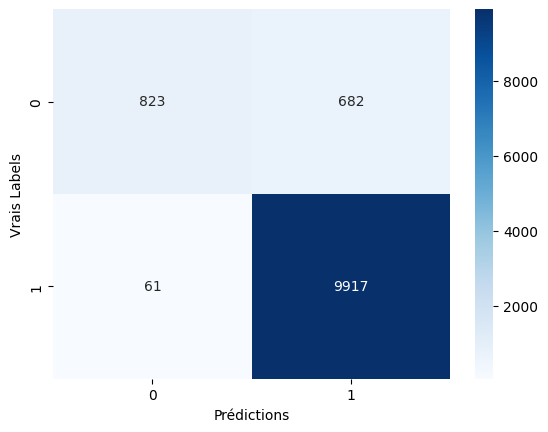

In [29]:
# 1. Obtenir les prédictions sur le dataset de test
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# 2. Créer la matrice
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédictions')
plt.ylabel('Vrais Labels')
plt.show()

In [35]:
def parser_donnees_test(chemin_fichier):
    donnees = []
    
    # L'expression régulière sans le groupe ([CM]) et son ":"
    # Elle capture :
    # 1. (\d+) : l'ID du document
    # 2. (\d+) : l'ID de la phrase
    # 3. (.*) : Le texte
    pattern = re.compile(r"<(\d+):(\d+)>\s*(.*)")
    
    with open(chemin_fichier, 'r', encoding='utf-8') as f:
        for ligne in f:
            match = pattern.match(ligne)
            if match:
                doc_id = int(match.group(1))
                sent_id = int(match.group(2))
                texte = match.group(3).strip()
                
                donnees.append({
                    'Doc_ID': doc_id,
                    'Sentence_ID': sent_id,
                    'Texte': texte
                })
                
    return pd.DataFrame(donnees)

# Chargement du DataFrame de test
# Remplace le chemin par celui de ton fichier test
df_test_final = parser_donnees_test("/kaggle/input/datasets/isaackinane/c-m-dialogue/corpus.tache1.test.utf8")
print(f"Nombre de lignes de test à prédire : {len(df_test_final)}")

Nombre de lignes de test à prédire : 27162


In [36]:
faux_labels = np.zeros(len(df_test_final))
test_submission_dataset = DialogueDataset(
    texts=df_test_final['Texte'].to_numpy(),
    labels=faux_labels,
    tokenizer=tokenizer,
    max_len=128
)

test_results = trainer.predict(test_submission_dataset)
logits = torch.from_numpy(test_results.predictions)
probabilities = softmax(logits, dim=-1).numpy()
prob_mitterrand = probabilities[:, 0]

df_sub = pd.DataFrame(prob_mitterrand)
df_sub.to_csv('submission-pres-1.csv', index=False, header=False)

print("Fichier généré. Voici les 5 premières lignes :")
print(prob_mitterrand[:5])
# On prend 2 exemples au hasard
for i in range(2):
    text = test_df['Texte'].iloc[i]
    p = prob_mitterrand[i]
    print(f"Texte: {text[:100]}...")
    print(f"Probabilité Mitterrand: {p:.4f}")
    print("Pronostic: " + ("Mitterrand" if p > 0.5 else "Chirac"))
    print("-" * 30)

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fichier généré. Voici les 5 premières lignes :
[0.00344165 0.00990064 0.11234859 0.9718022  0.59464496]
Texte: Je veux saluer celles et ceux qui ont lancé puis soutenu, neuf années durant, ce grand projet....
Probabilité Mitterrand: 0.0034
Pronostic: Chirac
------------------------------
Texte: Et pourtant, il est appelé à jouer un rôle essentiel pour que notre pays entre de plain-pied dans le...
Probabilité Mitterrand: 0.0099
Pronostic: Chirac
------------------------------


In [13]:
# 1. Chargement du modèle pour classification binaire (num_labels=2)
model = AutoModelForSequenceClassification.from_pretrained(
    "almanach/camembert-base", 
    num_labels=2
)
# 1. On calcule le poids pour rééquilibrer (39912 Chirac / 6018 Mitterrand = ~6.6)
# Classe 0 = Mitterrand (poids fort), Classe 1 = Chirac (poids normal)
class_weights = torch.tensor([6.6, 1.0]).to(device)

# 2. On crée notre Trainer sur-mesure
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # On applique la pénalité stricte si le modèle rate un Mitterrand
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

In [24]:
training_args = TrainingArguments(
    output_dir="./results_weight",
    num_train_epochs=1,             
    per_device_train_batch_size=16, 
    learning_rate=2e-5,             
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,    # Il gardera automatiquement la meilleure des 4 époques
    metric_for_best_model="f1",
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

KeyboardInterrupt: 

In [68]:
# On met à jour les arguments pour protéger l'époque 1
training_args_ep2 = TrainingArguments(
    output_dir="./results_epoque_2", # <-- NOUVEAU DOSSIER !
    num_train_epochs=1,              
    per_device_train_batch_size=32,
    learning_rate=2e-5,              
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

# On recrée le Trainer pondéré avec le MÊME modèle (qui est déjà à 94.7%)
trainer_ep2 = WeightedTrainer(
    model=model,
    args=training_args_ep2,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# C'est parti pour l'Époque 2 !
trainer_ep2.train()

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.320404,0.407425,0.950780,0.949071,0.952495


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=718, training_loss=0.32417311176948227, metrics={'train_runtime': 640.4629, 'train_samples_per_second': 71.714, 'train_steps_per_second': 1.121, 'total_flos': 3021172693171200.0, 'train_loss': 0.32417311176948227, 'epoch': 1.0})

In [69]:
print("Génération des prédictions en cours...")
predictions_output = trainer_ep2.predict(test_submission_dataset)
logits = torch.from_numpy(predictions_output.predictions)

# 2. Conversion en probabilités (Softmax)
probs = softmax(logits, dim=-1).numpy()

# 3. Extraction de la probabilité Mitterrand (Classe 0)
# Rappel : P > 0.5 donnera Mitterrand lors de la correction
prob_mitterrand = probs[:, 0]

# 4. Sauvegarde stricte (uniquement les valeurs, pas d'en-tête, pas d'index)
submission = pd.DataFrame(prob_mitterrand)
submission.to_csv('submission-pres-2.csv', index=False, header=False)

print("✅ Fichier submission-pres-2.csv généré avec succès !")

# Petit aperçu pour vérifier que c'est bien une liste de probabilités brutes
print("Aperçu des 5 premières prédictions :")
print(submission.head())

Génération des prédictions en cours...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✅ Fichier submission-pres-2.csv généré avec succès !
Aperçu des 5 premières prédictions :
          0
0  0.018101
1  0.054927
2  0.382638
3  0.957672
4  0.922828


In [10]:
import torch
from torch import nn
from transformers import Trainer

# 1. On calcule le poids pour rééquilibrer (39912 Chirac / 6018 Mitterrand = ~6.6)
# Classe 0 = Mitterrand (poids fort), Classe 1 = Chirac (poids normal)
class_weights = torch.tensor([6.6, 1.0]).to(device)

# 2. On crée notre Trainer sur-mesure
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # On applique la pénalité stricte si le modèle rate un Mitterrand
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./results_weight",
    num_train_epochs=1,             
    per_device_train_batch_size=16, 
    learning_rate=2e-5,             
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,    
    metric_for_best_model="f1",
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

KeyboardInterrupt: 

In [14]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(gss.split(train_df, groups=train_df['Doc_ID']))

df_train = train_df.iloc[train_idx].reset_index(drop=True)
df_eval = train_df.iloc[val_idx].reset_index(drop=True)

train_dataset = DialogueDataset(
    texts=df_train['Texte'].to_numpy(),
    labels=df_train['label_id'].to_numpy(),
    tokenizer=tokenizer,
    max_len=128
)

test_dataset = DialogueDataset(
    texts=df_eval['Texte'].to_numpy(),
    labels=df_eval['label_id'].to_numpy(),
    tokenizer=tokenizer,
    max_len=128
)

class_weights = torch.tensor([6.6, 1.0]).to("cuda")

# 2. On crée notre Trainer sur-mesure
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # On applique la pénalité stricte si le modèle rate un Mitterrand
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

In [31]:
model = AutoModelForSequenceClassification.from_pretrained(
    "almanach/camembert-base", 
    num_labels=2
)

training_args = TrainingArguments(
    output_dir="./results_weight",
    num_train_epochs=2,             
    per_device_train_batch_size=16, 
    learning_rate=2e-5,             
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,    # Il gardera automatiquement la meilleure des 4 époques
    metric_for_best_model="f1",
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--almanach--camembert-base/snapshots/a75967561c78f2aa81cc41045378d3b4ee25af9e/config.json
Model config CamembertConfig {
  "add_cross_attention": false,
  "architectures": [
    "CamembertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 5,
  "classifier_dropout": null,
  "eos_token_id": 6,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "camembert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 1,
  "transformers_version": "5.2.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 32005
}

loading weights file model.safetensors from cache at /root/.cache/huggingface/hub/models--almanach--camembert-base/snapshots/a75967561c78f2aa81

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: almanach/camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
PyTorch: setting up devices
***** Running training *****
  Num examples = 38,899
  Num Epochs = 2
  Ins

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.429269,0.372540,0.648971,0.599000,0.708038
2,0.303313,0.483955,0.648649,0.733234,0.581560



***** Running Evaluation *****
  Num examples = 7031
  Batch size = 16
Saving model checkpoint to ./results_weight/checkpoint-1216
Configuration saved in ./results_weight/checkpoint-1216/config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in ./results_weight/checkpoint-1216/model.safetensors

***** Running Evaluation *****
  Num examples = 7031
  Batch size = 16
Saving model checkpoint to ./results_weight/checkpoint-2432
Configuration saved in ./results_weight/checkpoint-2432/config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in ./results_weight/checkpoint-2432/model.safetensors


Training completed. Do not forget to share your model on huggingface.co/models =)


Loading best model from ./results_weight/checkpoint-1216 (score: 0.6489707475622969).
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.e

TrainOutput(global_step=2432, training_loss=0.3803518194901316, metrics={'train_runtime': 1228.5009, 'train_samples_per_second': 63.328, 'train_steps_per_second': 1.98, 'total_flos': 5117378471224320.0, 'train_loss': 0.3803518194901316, 'epoch': 2.0})

In [13]:
# 1. Quelle classe est 0 et quelle classe est 1 ?
print(train_df['label_id'].value_counts())

# 2. Distribution réelle
print(train_df['label_id'].value_counts(normalize=True))

# 3. F1 PAR classe sur ta validation
from sklearn.metrics import classification_report
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
print(classification_report(predictions.label_ids, preds, target_names=['classe_0', 'classe_1']))

label_id
1    39912
0     6018
Name: count, dtype: int64
label_id
1    0.868975
0    0.131025
Name: proportion, dtype: float64


NameError: name 'trainer' is not defined

In [9]:
def preparer_donnees_brutes(df, taille_fenetre=3):
    df_sorted = df.sort_values(by=['Doc_ID', 'Sentence_ID']).reset_index(drop=True)
    fenetres = []

    for doc_id, group in df_sorted.groupby('Doc_ID', sort=False):
        # On convertit les lignes du groupe en liste de dictionnaires
        lignes = group.to_dict('records') 
        N = len(lignes)

        for i in range(N):
            start = max(0, i - (taille_fenetre // 2))
            end = start + taille_fenetre
            
            # Compensation si on touche la fin
            if end > N:
                end = N
                start = max(0, end - taille_fenetre)
                
            # On stocke la structure de la fenêtre
            fenetre = {
                'avant': lignes[start:i], # Liste des phrases d'avant
                'cible': lignes[i],       # La phrase actuelle
                'apres': lignes[i+1:end]  # Liste des phrases d'après
            }
            fenetres.append(fenetre)
            
    df_sorted['Fenetre'] = fenetres
    return df_sorted

class PresidentsDataset(Dataset):
    def __init__(self, df, tokenizer, is_test=False, max_len=256, proba_masque=0.5):
        self.fenetres = df['Fenetre'].values
        self.tokenizer = tokenizer
        self.is_test = is_test
        self.max_len = max_len
        self.proba_masque = proba_masque # 50% de chance de cacher un label de contexte
        
        if not self.is_test:
            self.labels = df['label_id'].values 

    def format_phrase(self, phrase_dict, is_cible=False):
        texte = phrase_dict['Texte']
        
        if self.is_test:
            # En test, on ne sait JAMAIS qui parle, tout est masqué
            label_str = "?"
        else:
            if is_cible:
                # LA REGLE D'OR : La cible à deviner est TOUJOURS masquée à l'entraînement
                label_str = "?"
            else:
                # Pour le contexte : on applique ton idée de masquage aléatoire !
                if random.random() < self.proba_masque:
                    label_str = "?"
                else:
                    # On affiche le vrai label (C ou M)
                    label_str = phrase_dict.get('Label', '?')
                    
        return f"{label_str} : {texte}"

    def __len__(self):
        return len(self.fenetres)

    def __getitem__(self, idx):
        fenetre = self.fenetres[idx]
        
        # 1. Formatage dynamique des 3 parties
        textes_avant = [self.format_phrase(p, is_cible=False) for p in fenetre['avant']]
        cible_str = self.format_phrase(fenetre['cible'], is_cible=True)
        textes_apres = [self.format_phrase(p, is_cible=False) for p in fenetre['apres']]
        
        # 2. Assemblage avec les balises
        str_avant = " ".join(textes_avant)
        str_apres = " ".join(textes_apres)
        
        texte_final = f"<avant> {str_avant} <phrase> {cible_str} <apres> {str_apres}"
        texte_final = " ".join(texte_final.split())
        
        encoding = self.tokenizer(
            texte_final,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }
        
        if not self.is_test:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        else:
            item['labels'] = torch.tensor(0, dtype=torch.long)
            
        return item

In [10]:
train_df = preparer_donnees_brutes(train_df,taille_fenetre=10)

# 3. ON CRÉE LE DATASET VISUEL MAINTENANT QUE LA COLONNE EXISTE
dataset_visuel = PresidentsDataset(
    df=train_df, 
    tokenizer=tokenizer, 
    is_test=False, 
    max_len=512,
    proba_masque=0.5
)

print("=== PARTIE 1 : VÉRIFICATION DE 3 EXEMPLES DIFFÉRENTS ===\n")

for i in range(3):
    item = dataset_visuel[i] # Appel du __getitem__
    
    # On décode les IDs en texte lisible
    # skip_special_tokens=False pour qu'on puisse voir nos balises <avant>, <phrase>, etc.
    texte_decode = tokenizer.decode(item['input_ids'], skip_special_tokens=False)
    
    # Petit nettoyage visuel pour cacher les centaines de <pad> à la fin de la phrase
    texte_propre = texte_decode.replace("<pad>", "").strip()
    
    # Le label tensor(0) ou tensor(1)
    label = item['labels'].item() 
    nom_label = "Chirac" if label == 1 else "Mitterrand"
    
    print(f"--- LIGNE {i} (Vrai locuteur : {nom_label}) ---")
    print(texte_propre)
    print("")

print("-" * 60)
print("\n=== PARTIE 2 : DÉMONSTRATION DU MASQUAGE DYNAMIQUE (Même ligne appelée 3 fois) ===")
print("Observe bien les lettres avant et après la balise <phrase> : elles vont changer !\n")

index_test = 2 # Prenons la ligne 2 au hasard
for essai in range(3):
    item = dataset_visuel[index_test]
    texte_decode = tokenizer.decode(item['input_ids'], skip_special_tokens=False).replace("<pad>", "").strip()
    print(f"Essai {essai+1} :")
    print(texte_decode)
    print("")

=== PARTIE 1 : VÉRIFICATION DE 3 EXEMPLES DIFFÉRENTS ===

--- LIGNE 0 (Vrai locuteur : Chirac) ---
<s> <avant> <phrase> ? : Je voudrais d'abord vous remercier, Madame la Présidente, pour votre accueil, pour vos paroles pleines d'une chaleureuse amitié. <apres> C : Et croyez que c'est une amitié, dans mon coeur, réciproque à l'égard de votre pays et de ses représentants. C : Je ressens avec une émotion particulière l'honneur d'être le premier Président de la République française invité à s'adresser au Riksdag, l'un des plus anciens parlements du monde, et, à travers ses représentants, au peuple suédois tout entier. C : Je veux y voir le signe de l'amitié entre deux pays qui vont, l'un après l'autre, assurer la présidence de l'Union européenne. ? : Cette Europe fut longtemps le champ de bataille de nos vieilles nations. ? : Leur longue et solide alliance, Suédois et Français l'ont scellée aux heures terribles de la guerre de Trente Ans. C : Frères d'armes, Suédois et Français le furent s

In [15]:
# 1. Préparer les données avec fenêtre contextuelle
train_df = preparer_donnees_brutes(train_df,taille_fenetre=10)
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(gss.split(train_df, groups=train_df['Doc_ID']))
df_train = train_df.iloc[train_idx].reset_index(drop=True)
df_eval  = train_df.iloc[val_idx].reset_index(drop=True)

# 2. Préparer les fenêtres contextuelles SUR CHAQUE SPLIT SÉPARÉMENT
df_train = preparer_donnees_brutes(df_train, taille_fenetre=10)
df_eval  = preparer_donnees_brutes(df_eval,  taille_fenetre=10)


# 3. Créer les datasets
train_dataset = PresidentsDataset(
    df=df_train,
    tokenizer=tokenizer,
    is_test=False,
    max_len=512,
    proba_masque=0.5
)

eval_dataset = PresidentsDataset(
    df=df_eval,
    tokenizer=tokenizer,
    is_test=False,
    max_len=512,
    proba_masque=0.0   # ← pas de masque en éval ! on veut le vrai contexte
)

training_args = TrainingArguments(
    output_dir="./results_weight",
    num_train_epochs=2,             
    per_device_train_batch_size=16, 
    learning_rate=2e-5,             
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,    
    metric_for_best_model="f1",
    report_to="none",
    disable_tqdm=False, 
    logging_steps=10
)

# 4. Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,   
    eval_dataset=eval_dataset,     
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.077461,0.016858,0.986998,0.986998,0.986998
2,0.055765,0.012860,0.986479,0.981287,0.991726


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2432, training_loss=0.07179592835870464, metrics={'train_runtime': 4604.4374, 'train_samples_per_second': 16.896, 'train_steps_per_second': 0.528, 'total_flos': 2.046951388489728e+16, 'train_loss': 0.07179592835870464, 'epoch': 2.0})

In [20]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer

model_path = "./results_weight/checkpoint-2432"  # Le dossier où tu as sauvé ton entraînement
model_name = "almanach/camembert-base" # Le nom original pour le tokenizer

# 2. Chargement (CORRIGÉ)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# On charge le modèle depuis TON dossier local
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# 3. Créer le dataset d'évaluation
eval_dataset = PresidentsDataset(
    df=df_eval,
    tokenizer=tokenizer,
    is_test=False,
    max_len=256,
    proba_masque=0.0 # On garde le contexte réel pour le test
)
# On initialise un Trainer "léger" juste pour l'évaluation
trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics # Ta fonction de calcul (F1, Accuracy)
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [21]:
# 1. On calcule les fenêtres sur TOUT le train (pour être sûr d'avoir les voisins)
print("Calcul des fenêtres sur le corpus global...")
df_global = preparer_donnees_brutes(train_df, taille_fenetre=10)

# 2. On crée un dictionnaire de correspondance Texte -> Fenetre
# On drop les doublons de texte pour ne pas polluer la fusion
df_contextes = df_global[['Texte', 'Fenetre']].drop_duplicates(subset=['Texte'])

# 3. On injecte ces fenêtres dans ton fichier de test
df_test_final = pd.merge(
    test_df.drop(columns=['Fenetre'], errors='ignore'), 
    df_contextes, 
    on='Texte', 
    how='left'
)

print(f"Fusion terminée ! Nombre de lignes avec contexte : {df_test_final['Fenetre'].notna().sum()}")


class PresidentsDatasetFinal(Dataset):
    def __init__(self, df, tokenizer):
        # On convertit en liste de dict pour la rapidité
        self.data = df.to_dict('records')
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        f = row.get('Fenetre')
        
        # Initialisation par défaut si aucun contexte n'est trouvé (cas rare)
        txt_avant = ""
        txt_apres = ""
        
        # Si on a bien un dictionnaire de fenêtre (et pas un NaN)
        if isinstance(f, dict):
            # Construction des chaînes "M : texte" ou "C : texte"
            # On vérifie bien les clés 'label_id' et 'Texte' dans le dictionnaire p
            txt_avant = " ".join([f"{'M' if p.get('label_id')==0 else 'C'} : {p.get('Texte','')}" for p in f.get('avant', [])])
            txt_apres = " ".join([f"{'M' if p.get('label_id')==0 else 'C'} : {p.get('Texte','')}" for p in f.get('apres', [])])
        
        txt_cible = f"? : {row.get('Texte', '')}"
        
        # Assemblage final avec les balises
        texte_final = f"<avant> {txt_avant} <phrase> {txt_cible} <apres> {txt_apres}"
        # Nettoyage des espaces multiples
        texte_final = " ".join(texte_final.split())
        
        encoding = self.tokenizer(
            texte_final,
            truncation=True,
            padding='max_length',
            max_length=512,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(row.get('label_id', 0), dtype=torch.long)
        }

# Instanciation
test_dataset_final = PresidentsDatasetFinal(df_test_final, tokenizer)

Calcul des fenêtres sur le corpus global...
Fusion terminée ! Nombre de lignes avec contexte : 271


In [22]:
# --- 1. FONCTION SANS FRONTIÈRE ---
def fenetrage_continu(df, taille_fenetre=10):
    # On prend TOUTES les lignes d'un coup, sans faire de groupby('Doc_ID')
    lignes = df.to_dict('records')
    N = len(lignes)
    fenetres = []
    
    for i in range(N):
        start = max(0, i - (taille_fenetre // 2))
        end = min(N, start + taille_fenetre)
        
        # Ajustement si on est à la toute fin du fichier
        if end == N:
            start = max(0, N - taille_fenetre)
            
        fenetres.append({
            'avant': lignes[start:i],
            'cible': lignes[i],
            'apres': lignes[i+1:end]
        })
        
    df['Fenetre'] = fenetres
    return df

# --- 2. APPLICATION SUR TON DF GLOBAL ---

print("🔄 Préparation des données...")

# a) Sauvegarde de l'ordre d'origine pour la soumission
df_soum['ordre_original'] = range(len(df_soum))
train_df['ordre_original'] = -1
# b) Marquage pour retrouver les lignes plus tard
train_df['is_soum'] = False
df_soum['is_soum'] = True

# c) Fusion globale pour calculer les fenêtres sur TOUT
cols_communes = ['Doc_ID', 'Sentence_ID', 'Texte', 'is_soum', 'ordre_original']
# On s'assure que le label_id est bien dans train_df
if 'label_id' in train_df.columns:
    cols_communes_train = cols_communes + ['label_id']
else:
    cols_communes_train = cols_communes

df_global = pd.concat([train_df[cols_communes_train], df_soum[cols_communes]], ignore_index=True)

# d) Tri chronologique OBLIGATOIRE
df_global = df_global.sort_values(by=['Doc_ID', 'Sentence_ID']).reset_index(drop=True)

# e) Calcul des fenêtres continues
print("🪟 Calcul des fenêtres continues...")
df_global = fenetrage_continu(df_global, taille_fenetre=10)

# f) Ré-extraction de la soumission et remise dans l'ordre
df_final_soum = df_global[df_global['is_soum'] == True].copy()
df_final_soum = df_final_soum.sort_values(by='ordre_original').reset_index(drop=True)

# g) Ré-extraction du train 
df_final_train = df_global[df_global['is_soum'] == False].copy()

print(f"✅ Lignes Train prêtes : {len(df_final_train)} | Lignes Soumission prêtes : {len(df_final_soum)}")


# =================================================================
# 3. DÉFINITION DU DATASET
# =================================================================
# Map pour récupérer les labels du contexte (M ou C)
label_map = dict(zip(train_df['Texte'], train_df['label_id']))

class SubmissionDataset(Dataset):
    def __init__(self, df, tokenizer, label_map):
        self.data = df.to_dict('records')
        self.tokenizer = tokenizer
        self.label_map = label_map

    def __len__(self): return len(self.data)

    def format_contexte(self, p):
        txt = str(p.get('Texte', '')).strip()
        l_id = self.label_map.get(txt)
        # On affiche M ou C pour aider le modèle, sinon ?
        label_str = "M" if l_id == 0 else "C" if l_id == 1 else "?"
        return f"{label_str} : {txt}"

    def __getitem__(self, idx):
        row = self.data[idx]
        f = row['Fenetre']
        txt_avant = " ".join([self.format_contexte(p) for p in f['avant']])
        txt_apres = " ".join([self.format_contexte(p) for p in f['apres']])
        
        texte_final = f"<avant> {txt_avant} <phrase> ? : {row['Texte']} <apres> {txt_apres}"
        
        encoding = self.tokenizer(
            texte_final, truncation=True, padding='max_length', max_length=512, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }

submission_dataset = SubmissionDataset(df_final_soum, tokenizer, label_map)

🔄 Préparation des données...
🪟 Calcul des fenêtres continues...
✅ Lignes Train prêtes : 45930 | Lignes Soumission prêtes : 27162


In [19]:
# Test sur la première ligne
exemple = submission_dataset[0]
print("--- TEXTE DÉCODÉ POUR LA SOUMISSION ---")
print(tokenizer.decode(exemple['input_ids'], skip_special_tokens=False))

--- TEXTE DÉCODÉ POUR LA SOUMISSION ---
<s> <avant> C : C'est fort de cette conviction que je vais maintenant lever mon verre : en l'honneur de mon ami, son Excellence <nom> , Président de l'Afrique du Sud et grand combattant de l'humanité ; en l'honneur du vice- <nom> à qui je souhaite tous les courages et tous les succès ; en l'honneur des hautes personnalités sud-africaines et françaises qui nous font ce soir l'amitié de leur présence. C : Je lève mon verre au bonheur de l'Afrique du Sud et de son peuple, aux relations toujours plus étroites entre l'Afrique du Sud et la France, et à cet avenir que nous pouvons construire ensemble, dans une amitié et un respect mutuels et confiants. C : Monsieur le Président, mon cher Ami, permettez-moi de reprendre un instant la parole. C : Il m'est revenu que, cette année, dans un mois à peu près, vous franchissez, pour la quatrième fois, l'étape de vos vingt printemps : la première étape fut celle de la révélation ; la seconde, celle de la lutte ;

In [24]:
print("Génération des prédictions finales...")
model.eval()

# 1. Lancement de la prédiction
with torch.no_grad():
    output = trainer.predict(submission_dataset)
    logits = torch.from_numpy(output.predictions)
    probs = F.softmax(logits, dim=-1).numpy()

# 2. Extraction de la probabilité (Index 0 = Mitterrand)
prob_mitterrand = probs[:, 0]

# 3. Sauvegarde au format attendu (sans en-tête ni index)
pd.DataFrame(prob_mitterrand).to_csv('submission_finale.csv', index=False, header=False)

print(f"Terminé. Fichier 'submission_finale.csv' généré avec {len(prob_mitterrand)} lignes.")

# ==========================================
# 2. PRÉDICTIONS SUR LE FICHIER DE TRAIN
# ==========================================
print("\n🔮 2/2 - Génération des prédictions pour le TRAIN...")

# Pour le train, on recrée un dataset sans le "masquage aléatoire" (proba_masque=0.0)
# pour voir la vraie performance du modèle sur son propre texte avec tout le contexte.
train_eval_dataset = PresidentsDataset(
    df=train_df,         # Ton DataFrame d'entraînement d'origine avec les fenêtres
    tokenizer=tokenizer,
    is_test=False,       # is_test=False car on a les vrais labels
    max_len=512,
    proba_masque=0.0     # 0.0 = on laisse tous les "M :" et "C :" du contexte visibles !
)

with torch.no_grad():
    output_train = trainer.predict(train_eval_dataset)
    logits_train = torch.from_numpy(output_train.predictions)
    probs_train = F.softmax(logits_train, dim=-1).numpy()

prob_mitterrand_train = probs_train[:, 0]

# Pour le train, c'est très utile de sauvegarder aussi le VRAI label et le texte 
# pour pouvoir analyser les erreurs de ton modèle dans un fichier Excel.
df_train_preds = pd.DataFrame({
    'Prob_Mitterrand': prob_mitterrand_train,
    'Vrai_Label_ID': train_df['label_id'],
    'Texte': train_df['Texte']
})

# Ici on garde les en-têtes car c'est un fichier d'analyse pour toi
df_train_preds.to_csv('predictions_sur_le_train.csv', header=True)
print(f"✅ Fichier 'predictions_sur_le_train.csv' sauvegardé ({len(prob_mitterrand_train)} lignes).")

print("\n🎉 TOUT EST FINI ! Tu peux envoyer ton fichier de soumission.")

Génération des prédictions finales...
Terminé. Fichier 'submission_finale.csv' généré avec 27162 lignes.

🔮 2/2 - Génération des prédictions pour le TRAIN...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


✅ Fichier 'predictions_sur_le_train.csv' sauvegardé (45930 lignes).

🎉 TOUT EST FINI ! Tu peux envoyer ton fichier de soumission.


In [25]:
df_train_preds.to_csv('predictions_sur_le_train.csv')